In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from azure.cosmos import CosmosClient
from collections import Counter

from scipy.stats import linregress

URL = "https://aegiscosmosdb.documents.azure.com"
KEY = "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==" 
DATABASE_NAME = "aegisraw"
CONTAINER_NAME = "openalex-authors"

In [3]:
# ==========================================
# Fetch Authors Data from CosmosDB
# ==========================================
print("Connecting to Cosmos DB...")
client = CosmosClient(URL, credential=KEY)
database = client.get_database_client(DATABASE_NAME)
container = database.get_container_client(CONTAINER_NAME)

query = """
SELECT 
    c.display_name, 
    c.works_count, 
    c.cited_by_count 
FROM c 
WHERE IS_DEFINED(c.works_count) AND IS_DEFINED(c.cited_by_count)
"""

print("Executing query... grab a coffee, this might take a minute.")
items = list(container.query_items(query=query, enable_cross_partition_query=True))
df_authors = pd.DataFrame(items)

df_authors['works_count'] = pd.to_numeric(df_authors['works_count'], errors='coerce')
df_authors['cited_by_count'] = pd.to_numeric(df_authors['cited_by_count'], errors='coerce')
df_authors = df_authors[df_authors['works_count'] > 0]

print(f"Success! Loaded {len(df_authors)} authors into memory.")

Connecting to Cosmos DB...
Executing query... grab a coffee, this might take a minute.
Success! Loaded 5841451 authors into memory.


In [4]:
# ==========================================
# Fetch Works Data from CosmosDB
# ==========================================
WORKS_CONTAINER_NAME = "openalex-works"
works_container = database.get_container_client(WORKS_CONTAINER_NAME)

# We only select the specific arrays we need to keep the memory footprint tiny
works_query = """
SELECT 
    c.authorships, 
    c.topics 
FROM c 
WHERE ARRAY_LENGTH(c.authorships) > 0 AND ARRAY_LENGTH(c.topics) > 0
"""

print("Executing Works query... fetching authors and topics.")
works_items = list(works_container.query_items(query=works_query, enable_cross_partition_query=True))

print(f"Success! Loaded {len(works_items):,} works into memory.")

Executing Works query... fetching authors and topics.
Success! Loaded 2,440,463 works into memory.


In [5]:
# ==========================================
# Extract Author-Topic Relationships
# ==========================================
print("Flattening JSON and extracting author-topic pairs...")

author_topic_pairs = []

for work in works_items:
    # Safely extract all author IDs from this specific work
    author_ids = [
        a.get('author', {}).get('id') 
        for a in work.get('authorships', []) 
        if a.get('author', {}).get('id')
    ]
    
    # Safely extract all topic IDs from this specific work
    topic_ids = [
        t.get('id') 
        for t in work.get('topics', []) 
        if t.get('id')
    ]
    
    # Link every author on the paper to every topic on the paper
    for a_id in author_ids:
        for t_id in topic_ids:
            author_topic_pairs.append({'author_id': a_id, 'topic_id': t_id})

# Convert to a DataFrame
df_author_topics = pd.DataFrame(author_topic_pairs)

# Group by author and count UNIQUE topics
author_stats_df = df_author_topics.groupby('author_id')['topic_id'].nunique().reset_index(name='unique_topics')

print(f"Success! Mapped {len(df_author_topics):,} total topic tags across {len(author_stats_df):,} unique authors.")

Flattening JSON and extracting author-topic pairs...
Success! Mapped 11,040,215 total topic tags across 3,349,799 unique authors.


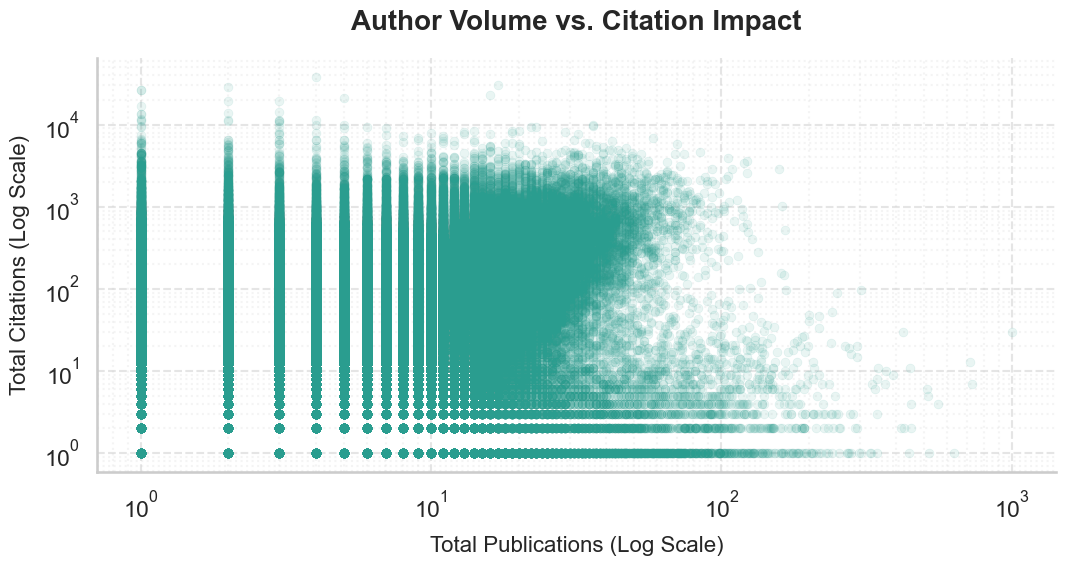

In [6]:
# ==========================================
# Plot Volume vs. Citation Data 
# ==========================================
plt.figure(figsize=(11, 6))

sns.set_theme(style="whitegrid", context="talk") 

# Filter out 0s just to be absolutely safe with the log-scale math
plot_df = df_authors[(df_authors['works_count'] > 0) & (df_authors['cited_by_count'] > 0)]

ax = sns.scatterplot(
    data=plot_df, 
    x='works_count', 
    y='cited_by_count', 
    alpha=0.1,
    s=40,
    edgecolor=None,
    color='#2A9D8F'
)

plt.xscale('log')
plt.yscale('log')

plt.title('Author Volume vs. Citation Impact', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Total Publications (Log Scale)', fontsize=16, labelpad=10)
plt.ylabel('Total Citations (Log Scale)', fontsize=16, labelpad=10)

# Clean up grid and borders
sns.despine()
ax.grid(True, which="major", ls="--", alpha=0.5)
ax.grid(True, which="minor", ls=":", alpha=0.2)

plt.tight_layout()
plt.show()

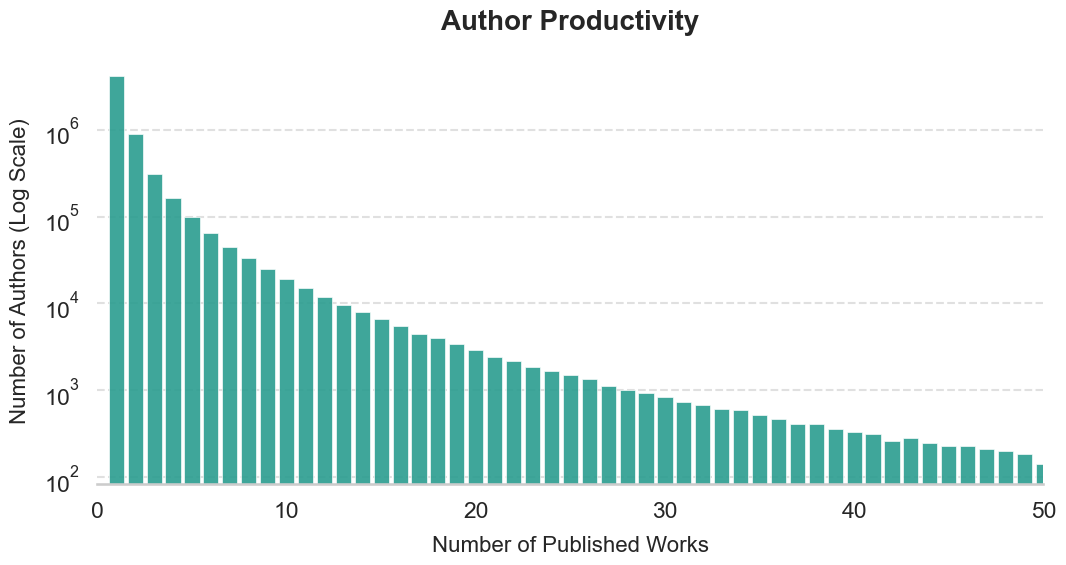

In [7]:
# ==========================================
# Plot Author Productivity Data 
# ==========================================
plt.figure(figsize=(11, 6))

# Set a modern, clean style with larger fonts for presentations
sns.set_theme(style="whitegrid", context="talk") 

# Filter the data 
filtered_authors = df_authors[(df_authors['works_count'] > 0) & (df_authors['works_count'] <= 50)]

# Calculate the exact counts manually
counts = filtered_authors['works_count'].value_counts().sort_index()

plt.bar(
    counts.index, 
    counts.values, 
    color='#2A9D8F',       
    edgecolor='white',     
    linewidth=0.5,         
    alpha=0.9,
    log=True  
)

plt.title('Author Productivity', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Number of Published Works', fontsize=16, labelpad=10)
plt.ylabel('Number of Authors (Log Scale)', fontsize=16, labelpad=10)

# Clean up borders and grid
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.grid(axis='x', visible=False)

plt.xlim(0, 50) 
plt.tight_layout()
plt.show()

In [8]:
# ==========================================
# Display Productivit/Impact Data 
# ==========================================
total_authors = len(df_authors)

# --- SLIDE 1 STATS: PRODUCTIVITY ---
one_paper = len(df_authors[df_authors['works_count'] == 1])
ten_plus_papers = len(df_authors[df_authors['works_count'] >= 10])

one_paper_pct = (one_paper / total_authors) * 100
ten_plus_pct = (ten_plus_papers / total_authors) * 100

# --- SLIDE 2 STATS: IMPACT ---
zero_cites = len(df_authors[df_authors['cited_by_count'] == 0])
hundred_plus_cites = len(df_authors[df_authors['cited_by_count'] >= 100])

zero_cites_pct = (zero_cites / total_authors) * 100
hundred_plus_pct = (hundred_plus_cites / total_authors) * 100

# Calculate correlation between volume and impact
correlation = df_authors['works_count'].corr(df_authors['cited_by_count'])

# --- PRINT FORMATTED RESULTS ---
print("--- SLIDE 1: PRODUCTIVITY STATS ---")
print(f"Total Authors Analyzed: {total_authors:,}")
print(f"One-and-Done Authors (1 paper): {one_paper_pct:.1f}% ({one_paper:,} people)")
print(f"Potential SMEs (10+ papers): {ten_plus_pct:.1f}% ({ten_plus_papers:,} people)")
print("-" * 40)
print("--- SLIDE 2: IMPACT STATS ---")
print(f"Unvalidated Authors (0 citations): {zero_cites_pct:.1f}% ({zero_cites:,} people)")
print(f"Highly Validated SMEs (100+ citations): {hundred_plus_pct:.1f}% ({hundred_plus_cites:,} people)")
print(f"Volume-to-Impact Correlation: {correlation:.2f} (1.0 is a perfect match)")

--- SLIDE 1: PRODUCTIVITY STATS ---
Total Authors Analyzed: 5,841,451
One-and-Done Authors (1 paper): 70.1% (4,096,118 people)
Potential SMEs (10+ papers): 2.0% (116,877 people)
----------------------------------------
--- SLIDE 2: IMPACT STATS ---
Unvalidated Authors (0 citations): 63.1% (3,686,126 people)
Highly Validated SMEs (100+ citations): 2.8% (166,420 people)
Volume-to-Impact Correlation: 0.00 (1.0 is a perfect match)


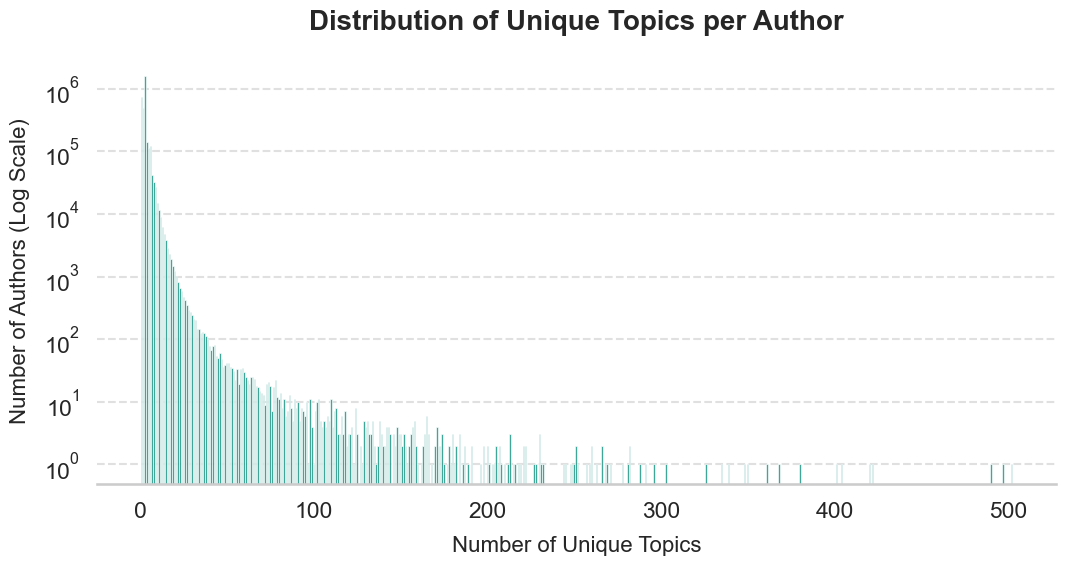

Total Authors Analyzed: 3,349,799
Hyper-Specialists (1-5 topics): 91.2% (3,056,585 people)
Generalists (>20 topics): 0.2% (8,213 people)


In [9]:
# ==========================================
# Plot Author Distribution Data 
# ==========================================
plt.figure(figsize=(11, 6))

# Match the presentation theme
sns.set_theme(style="whitegrid", context="talk") 

all_topics = author_stats_df['unique_topics']

# Calculate exact counts for the log scale
counts = all_topics.value_counts().sort_index()

# Draw the bars
plt.bar(
    counts.index, 
    counts.values, 
    color='#2A9D8F',       
    edgecolor='white',     
    linewidth=0.5,         
    alpha=0.9,
    log=True  
)

# Titles and Labels
plt.title('Distribution of Unique Topics per Author', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Number of Unique Topics', fontsize=16, labelpad=10)
plt.ylabel('Number of Authors (Log Scale)', fontsize=16, labelpad=10)

# Clean up grid and borders
sns.despine(left=True)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.grid(axis='x', visible=False)

plt.tight_layout()
plt.show()

# --- PRINT STATS ---
total_authors = len(all_topics)
specialists = len(all_topics[all_topics <= 5])
specialists_pct = (specialists / total_authors) * 100 if total_authors > 0 else 0

generalists = len(all_topics[all_topics > 20])
generalists_pct = (generalists / total_authors) * 100 if total_authors > 0 else 0

print(f"Total Authors Analyzed: {total_authors:,}")
print(f"Hyper-Specialists (1-5 topics): {specialists_pct:.1f}% ({specialists:,} people)")
print(f"Generalists (>20 topics): {generalists_pct:.1f}% ({generalists:,} people)")

In [15]:
# ==========================================
# Topic Distribution for Multi-Paper Authors
# ==========================================
print("Analyzing topic distribution for authors with multiple papers...")

# Count distinct papers per author from original works data
author_paper_counts = []
for work in works_items:
    author_ids = [
        a.get('author', {}).get('id') 
        for a in work.get('authorships', []) 
        if a.get('author', {}).get('id')
    ]
    for a_id in author_ids:
        author_paper_counts.append(a_id)

# Count papers per author
papers_per_author_dict = Counter(author_paper_counts)
df_paper_counts = pd.DataFrame(list(papers_per_author_dict.items()), columns=['author_id', 'paper_count'])

# Merge with topic stats
author_complete = author_stats_df.merge(df_paper_counts, on='author_id', how='inner')

# Filter for authors with more than one paper
multi_paper_authors = author_complete[author_complete['paper_count'] > 1]

print(f"\nTotal authors with multiple papers: {len(multi_paper_authors):,}")
print(f"Percentage of all authors: {(len(multi_paper_authors)/len(author_stats_df))*100:.1f}%")

# Calculate statistics
print("\n--- TOPIC DISTRIBUTION STATISTICS ---")
print(f"Mean unique topics: {multi_paper_authors['unique_topics'].mean():.2f}")
print(f"Median unique topics: {multi_paper_authors['unique_topics'].median():.1f}")
print(f"Std deviation: {multi_paper_authors['unique_topics'].std():.2f}")
print(f"Min topics: {multi_paper_authors['unique_topics'].min()}")
print(f"Max topics: {multi_paper_authors['unique_topics'].max()}")

# Calculate percentiles
print("\n--- TOPIC DIVERSITY BREAKDOWN ---")
q25 = multi_paper_authors['unique_topics'].quantile(0.25)
q50 = multi_paper_authors['unique_topics'].quantile(0.50)
q75 = multi_paper_authors['unique_topics'].quantile(0.75)
q90 = multi_paper_authors['unique_topics'].quantile(0.90)

print(f"25th percentile: {q25:.1f} topics")
print(f"50th percentile (median): {q50:.1f} topics")
print(f"75th percentile: {q75:.1f} topics")
print(f"90th percentile: {q90:.1f} topics")

# Calculate topic diversity categories
narrow_specialists = len(multi_paper_authors[multi_paper_authors['unique_topics'] <= 3])
moderate_specialists = len(multi_paper_authors[(multi_paper_authors['unique_topics'] > 3) & 
                                                (multi_paper_authors['unique_topics'] <= 10)])
broad_researchers = len(multi_paper_authors[(multi_paper_authors['unique_topics'] > 10) & 
                                             (multi_paper_authors['unique_topics'] <= 20)])
generalists = len(multi_paper_authors[multi_paper_authors['unique_topics'] > 20])

total = len(multi_paper_authors)
print("\n--- RESEARCHER PROFILES ---")
print(f"Narrow Specialists (1-3 topics): {(narrow_specialists/total)*100:.1f}% ({narrow_specialists:,} authors)")
print(f"Moderate Specialists (4-10 topics): {(moderate_specialists/total)*100:.1f}% ({moderate_specialists:,} authors)")
print(f"Broad Researchers (11-20 topics): {(broad_researchers/total)*100:.1f}% ({broad_researchers:,} authors)")
print(f"Generalists (>20 topics): {(generalists/total)*100:.1f}% ({generalists:,} authors)")

Analyzing topic distribution for authors with multiple papers...

Total authors with multiple papers: 650,543
Percentage of all authors: 19.4%

--- TOPIC DISTRIBUTION STATISTICS ---
Mean unique topics: 6.14
Median unique topics: 5.0
Std deviation: 5.91
Min topics: 1
Max topics: 502

--- TOPIC DIVERSITY BREAKDOWN ---
25th percentile: 4.0 topics
50th percentile (median): 5.0 topics
75th percentile: 7.0 topics
90th percentile: 10.0 topics

--- RESEARCHER PROFILES ---
Narrow Specialists (1-3 topics): 16.5% (107,017 authors)
Moderate Specialists (4-10 topics): 75.3% (490,138 authors)
Broad Researchers (11-20 topics): 6.9% (45,175 authors)
Generalists (>20 topics): 1.3% (8,213 authors)


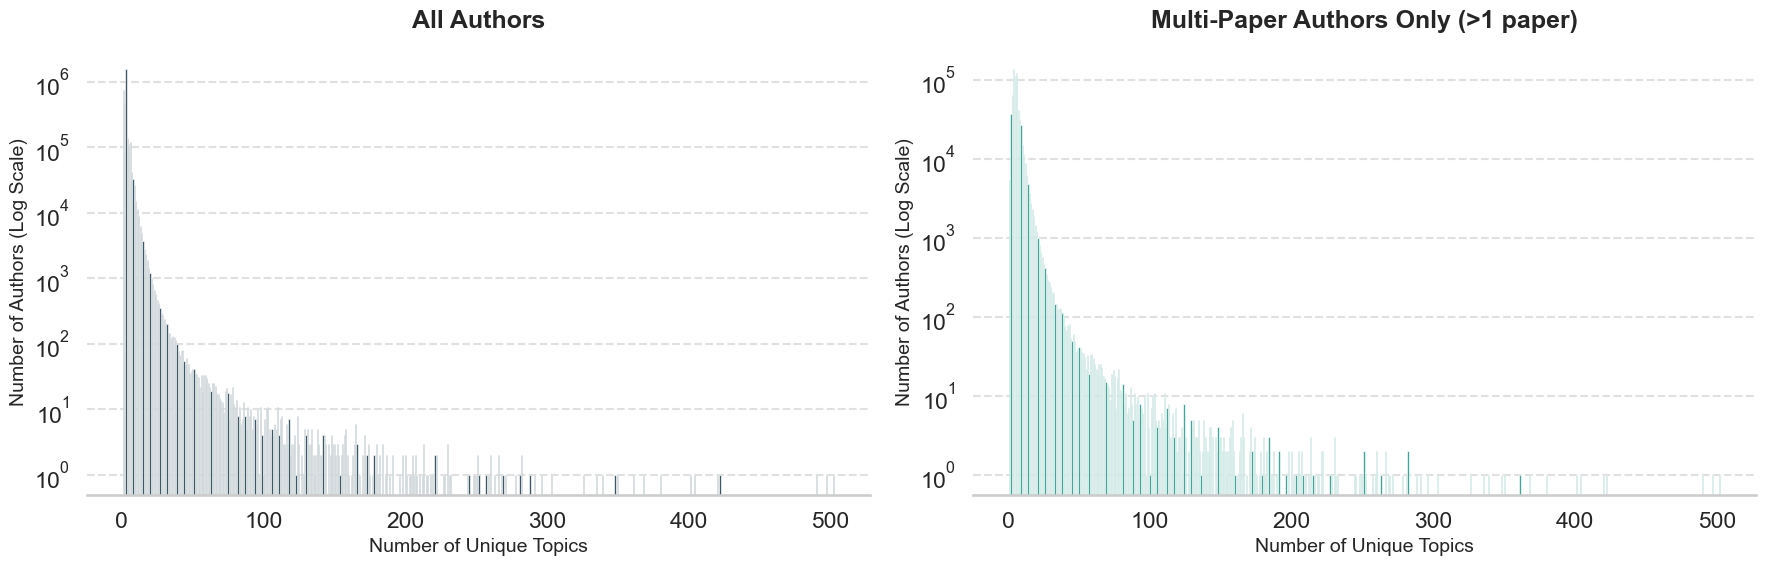

In [16]:
# ==========================================
# Visualize Topic Distribution for Multi-Paper Authors
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.set_theme(style="whitegrid", context="talk")

# Plot 1: All authors
ax1 = axes[0]
all_counts = author_stats_df['unique_topics'].value_counts().sort_index()
ax1.bar(all_counts.index, all_counts.values, color='#264653', alpha=0.9, 
        edgecolor='white', linewidth=0.5, log=True)
ax1.set_title('All Authors', fontsize=18, fontweight='bold', pad=15)
ax1.set_xlabel('Number of Unique Topics', fontsize=14)
ax1.set_ylabel('Number of Authors (Log Scale)', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.grid(axis='x', visible=False)
sns.despine(ax=ax1, left=True)

# Plot 2: Multi-paper authors only
ax2 = axes[1]
multi_counts = multi_paper_authors['unique_topics'].value_counts().sort_index()
ax2.bar(multi_counts.index, multi_counts.values, color='#2A9D8F', alpha=0.9, 
        edgecolor='white', linewidth=0.5, log=True)
ax2.set_title('Multi-Paper Authors Only (>1 paper)', fontsize=18, fontweight='bold', pad=15)
ax2.set_xlabel('Number of Unique Topics', fontsize=14)
ax2.set_ylabel('Number of Authors (Log Scale)', fontsize=14)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.grid(axis='x', visible=False)
sns.despine(ax=ax2, left=True)

plt.tight_layout()
plt.show()

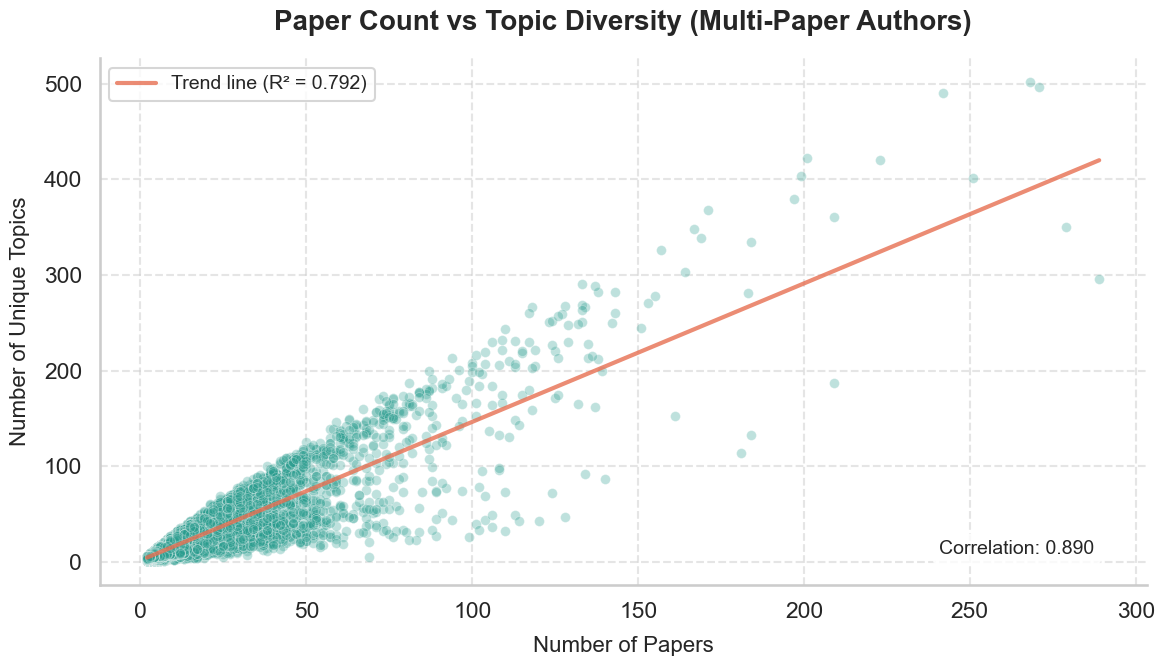


Correlation between paper count and topic diversity: 0.890
R-squared: 0.792


In [17]:
# ==========================================
# Paper Count vs Topic Diversity for Multi-Paper Authors
# ==========================================
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid", context="talk")

# Create scatter plot with density
ax = sns.scatterplot(
    data=multi_paper_authors, 
    x='paper_count', 
    y='unique_topics', 
    alpha=0.3,
    s=50,
    color='#2A9D8F'
)

# Add a trend line
slope, intercept, r_value, p_value, std_err = linregress(
    multi_paper_authors['paper_count'], 
    multi_paper_authors['unique_topics']
)
line_x = range(int(multi_paper_authors['paper_count'].min()), 
               int(multi_paper_authors['paper_count'].max()) + 1)
line_y = [slope * x + intercept for x in line_x]
plt.plot(line_x, line_y, color='#E76F51', linewidth=3, alpha=0.8, 
         label=f'Trend line (R² = {r_value**2:.3f})')

plt.title('Paper Count vs Topic Diversity (Multi-Paper Authors)', 
          fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Number of Papers', fontsize=16, labelpad=10)
plt.ylabel('Number of Unique Topics', fontsize=16, labelpad=10)
plt.legend(fontsize=14)

# Calculate and display correlation
correlation = multi_paper_authors['paper_count'].corr(multi_paper_authors['unique_topics'])
plt.text(0.95, 0.05, f'Correlation: {correlation:.3f}', 
         transform=ax.transAxes, 
         fontsize=14, 
         verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

sns.despine()
ax.grid(True, which="major", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nCorrelation between paper count and topic diversity: {correlation:.3f}")
print(f"R-squared: {r_value**2:.3f}")